In [98]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [99]:
df=pd.read_csv('HR_Attrition.csv')

In [100]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [101]:
df.shape

(1470, 35)

In [102]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
target_col = "Attrition"
print("Target Column:", target_col)

Target Column: Attrition


In [105]:
attrition_counts = df[target_col].value_counts()
print("\nEmployee Attrition Counts:")
print(attrition_counts)


Employee Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [106]:
left = attrition_counts.get("Yes", 0)
stayed = attrition_counts.get("No", 0)
attrition_rate = (left / len(df)) * 100
print(f"\nEmployees Left: {left}")
print(f"Employees Stayed: {stayed}")
print(f"Attrition Rate: {attrition_rate:.2f}%")


Employees Left: 237
Employees Stayed: 1233
Attrition Rate: 16.12%


In [107]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nNumber of Numeric Columns: {len(numeric_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")
print("\nNumeric Columns:")
print(list(numeric_cols))
print("\nCategorical Columns:")
print(list(categorical_cols))


Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [108]:
#Approximately 16% of employees experienced attrition, whereas about 84% remained
#The dataset is imbalanced because the majority of employees stayed with the company while a much smaller proportion left.

In [109]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [110]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [111]:
columns_to_drop = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df.drop(columns=columns_to_drop, inplace=True)

In [112]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})


In [113]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [114]:
X = pd.get_dummies(X,drop_first=True)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)


In [115]:
print("Shape after preprocessing:", X_scaled.shape)

print("\nFirst 5 rows:")
print(X_scaled.head())

print("\nTarget Distribution:")
print(y.value_counts())

Shape after preprocessing: (1470, 44)

First 5 rows:
        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.6

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y      # maintains the class distribution
)

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [118]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [119]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

In [122]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500
1,Random Forest,0.833333,0.375000,0.063830,0.109091


Interpretation

1. Logistic Regression
Lowest accuracy (74.8%)
Highest Recall (61.7%)
Highest F1 Score (0.439)

This means it identifies most employees who are likely to leave.best choice for HR, where missing an employee who may leave is usually more costly than investigating someone who stays.

2. Gradient Boosting
Highest Accuracy (85.0%)
Highest Precision (58.8%)
Low Recall (21.3%)

When it predicts someone will leave, it is often correct, but it misses many employees who actually leave.

3. Random Forest
Good Accuracy (83.3%)
Very poor Recall (6.4%)
Lowest F1 Score

The model predicts the majority class ("No Attrition") most of the time. This is why accuracy looks high while recall is extremely low.

In [123]:
# ROC-AUC

from sklearn.metrics import roc_auc_score

# for Logistic Regression
y_prob = lr.predict_proba(X_test)[:,1]
roc1 = roc_auc_score(y_test, y_prob)
print("ROC-AUC for Logistic Regression:", roc1)

# for Random Forest
y_prob = rf.predict_proba(X_test)[:,1]
roc2 = roc_auc_score(y_test, y_prob)
print("ROC-AUC for Random Forest:", roc2)

# for Gradient Boosting
y_prob = gb.predict_proba(X_test)[:,1]
roc3 = roc_auc_score(y_test, y_prob)
print("ROC-AUC for Gradient Boosting:", roc3)

ROC-AUC for Logistic Regression: 0.798604530967353
ROC-AUC for Random Forest: 0.7519166164182962
ROC-AUC for Gradient Boosting: 0.7941252476526832


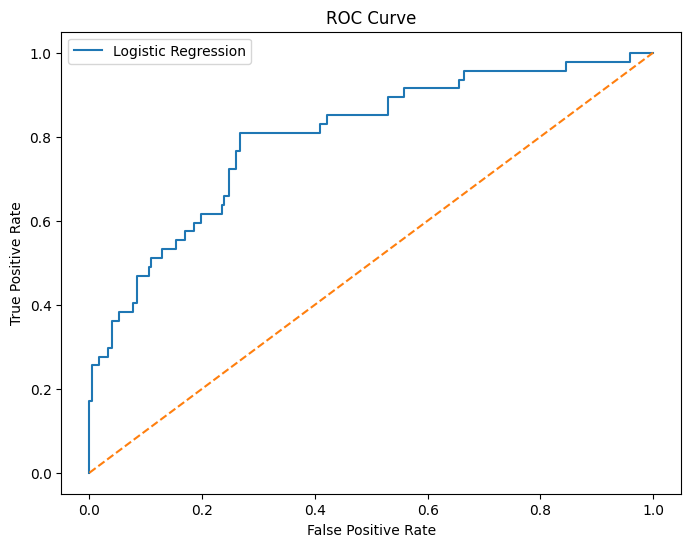

In [124]:
#ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

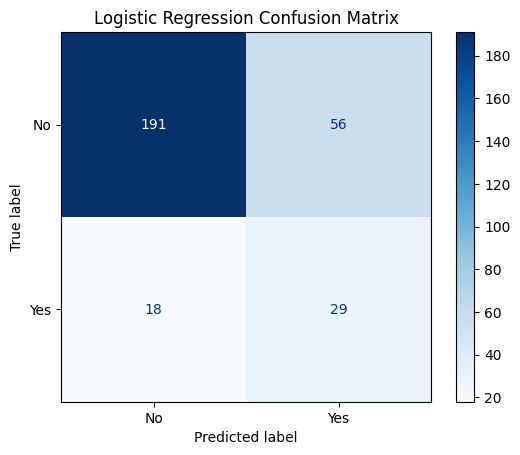

In [125]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No", "Yes"])

disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

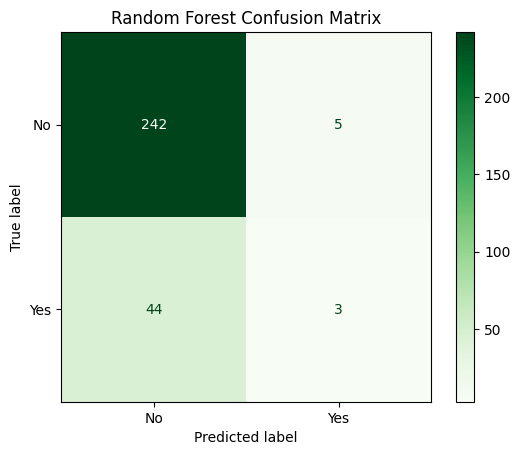

In [126]:
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No", "Yes"])

disp.plot(cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

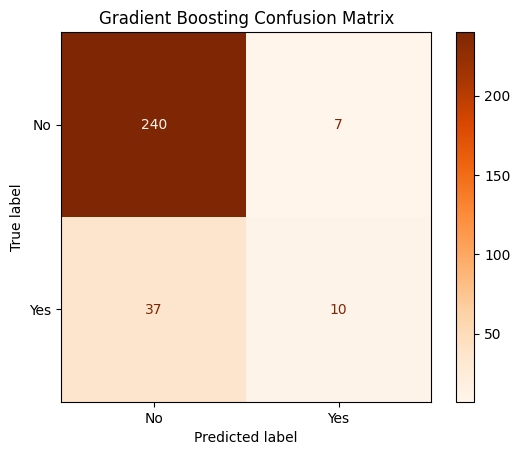

In [127]:
y_pred = gb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No", "Yes"])

disp.plot(cmap="Oranges")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()